<a href="https://colab.research.google.com/github/MaheeshaSawandi/Safehood/blob/Prediction-Model/RF1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc
)

import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel(
    "/content/drive/MyDrive/SafeHood_ML/Dataset/processed_dataset.xlsx"
)

df.head()

,Location,Year,Month,Crime_Count,Average_Severity,Maximum_Severity,Next_Month_Crime,Future_Risk
0,Abhayapura,2016,1,26,6.846154,10,33.0,High
1,Abhayapura,2016,2,33,6.606061,10,19.0,Medium
2,Abhayapura,2016,3,19,7.157895,10,21.0,Medium
3,Abhayapura,2016,4,21,7.000000,10,15.0,Medium
4,Abhayapura,2016,5,15,6.000000,10,28.0,Medium


In [ ]:
print(df.shape)

df.info()

(5638, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5638 entries, 0 to 5637
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Location          5638 non-null   object 
 1   Year              5638 non-null   int64  
 2   Month             5638 non-null   int64  
 3   Crime_Count       5638 non-null   int64  
 4   Average_Severity  5638 non-null   float64
 5   Maximum_Severity  5638 non-null   int64  
 6   Next_Month_Crime  5570 non-null   float64
 7   Future_Risk       5638 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 352.5+ KB


In [ ]:
df.isnull().sum()

,0
Location,0
Year,0
Month,0
Crime_Count,0
Average_Severity,0
Maximum_Severity,0
Next_Month_Crime,68
Future_Risk,0


In [ ]:
df = df.dropna()

In [ ]:
df["Future_Risk"].value_counts()

,count
Future_Risk,
Medium,2737
Low,2557
High,276


In [ ]:
encoder = LabelEncoder()

df["Location_Code"] = encoder.fit_transform(
    df["Location"]
)

In [ ]:
features = [

"Location_Code",

"Year",

"Month",

"Crime_Count",

"Average_Severity",

"Maximum_Severity"

]


X = df[features]

y = df["Future_Risk"]

In [ ]:
train = df[df["Year"] <= 2023]

test = df[df["Year"] > 2023]

In [ ]:
X_train = train[features]

X_test = test[features]


y_train = train["Future_Risk"]

y_test = test["Future_Risk"]

In [ ]:
print(X_train.shape)

print(X_test.shape)

(4539, 6)
(1031, 6)


In [ ]:
rf100 = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)


rf100.fit(
    X_train,
    y_train
)


prediction = rf100.predict(
    X_test
)

In [ ]:
print(
"Accuracy:",
accuracy_score(
    y_test,
    prediction
)
)


print(
"Precision:",
precision_score(
    y_test,
    prediction,
    average="weighted"
)
)


print(
"Recall:",
recall_score(
    y_test,
    prediction,
    average="weighted"
)
)


print(
"F1:",
f1_score(
    y_test,
    prediction,
    average="weighted"
)
)

Accuracy: 0.9398642095053347
Precision: 0.9063570990046103
Recall: 0.9398642095053347
F1: 0.9167561342675653


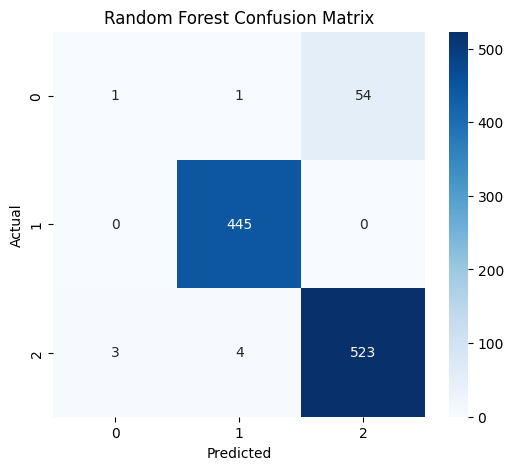

In [ ]:
cm = confusion_matrix(
    y_test,
    prediction
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
"Random Forest Confusion Matrix"
)

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature": features,

    "Importance": rf100.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
3,Crime_Count,0.517353
5,Maximum_Severity,0.227196
4,Average_Severity,0.141442
0,Location_Code,0.062164
2,Month,0.028237
1,Year,0.023607


In [ ]:
import joblib

joblib.dump(

    rf100,

    "/content/drive/MyDrive/SafeHood_ML/Models/random_forest_100.pkl"

)

['/content/drive/MyDrive/SafeHood_ML/Models/random_forest_100.pkl']